# Cluster Demand Comparison

This notebook compares two SKU clustering schemes:
- **Demand-only** clusters (`../data/processed/byregion/sku_clusters_demand_only.csv`)
- **Price/promo-only** clusters (`../data/processed/byregion/sku_clusters_price_promo.csv`)

It visualizes:
- Region-date demand heatmaps (aggregated)
- Sparsity and variance heatmaps by cluster-region
- Per-cluster distributions of per-SKU demand and price


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
root = Path('.').resolve()

# Input files
orders_path = root / '../data/raw/JD_order_data.csv'
network_path = root / '../data/raw/JD_network_data.csv'
clusters_demand_path = root / '../data/processed/byregion/sku_clusters_demand_only.csv'
clusters_price_path = root / '../data/processed/byregion/sku_clusters_price_promo.csv'

# Precomputed demand grids (if already generated)
demand_grid_demand_path = root / '../data/processed/byregion/cluster_region_daily_demand_demand_only.csv'
demand_grid_price_path = root / '../data/processed/byregion/cluster_region_daily_demand_price_promo.csv'
summary_demand_path = root / '../data/processed/byregion/cluster_region_daily_demand_summary_demand_only.csv'
summary_price_path = root / '../data/processed/byregion/cluster_region_daily_demand_summary_price_promo.csv'

print(root)


/mnt/e/capstonejd


## Load data


In [2]:
orders = pd.read_csv(
    orders_path,
    usecols=[
        'order_date', 'sku_ID', 'quantity', 'dc_des',
        'final_unit_price', 'original_unit_price',
        'direct_discount_per_unit', 'quantity_discount_per_unit',
        'bundle_discount_per_unit', 'coupon_discount_per_unit',
        'type'
    ]
)
orders['order_date'] = pd.to_datetime(orders['order_date'], errors='coerce')
orders = orders.dropna(subset=['order_date'])

network = pd.read_csv(network_path)

clusters_demand = pd.read_csv(clusters_demand_path)
clusters_price = pd.read_csv(clusters_price_path)

display(orders.head())
display(clusters_demand.head())
display(clusters_price.head())


,sku_ID,order_date,quantity,type,original_unit_price,final_unit_price,direct_discount_per_unit,quantity_discount_per_unit,bundle_discount_per_unit,coupon_discount_per_unit,dc_des
0,581d5b54c1,2018-03-01,1,2,89.0,79.0,0.0,10.0,0.0,0.0,28
1,067b673f2b,2018-03-01,1,1,99.9,53.9,5.0,41.0,0.0,0.0,28
2,623d0a582a,2018-03-01,1,1,78.0,58.5,19.5,0.0,0.0,0.0,28
3,fc5289b139,2018-03-01,1,1,61.0,35.0,0.0,26.0,0.0,0.0,28
4,623d0a582a,2018-03-01,1,1,78.0,53.0,19.0,0.0,0.0,6.0,16


,sku_ID,sku_cluster_ID
0,000aa92b82,11
1,000d4af39d,7
2,000dc27e13,1
3,000e84e3a7,1
4,00104dbcd7,0


,sku_ID,sku_cluster_ID
0,000aa92b82,9
1,000d4af39d,2
2,000dc27e13,14
3,000e84e3a7,0
4,00104dbcd7,14


## Helper functions


In [7]:
def build_demand_grid(orders_df, clusters_df, network_df):
    df = orders_df.merge(clusters_df, on='sku_ID', how='left')
    df = df.merge(network_df, left_on='dc_des', right_on='dc_ID', how='left')
    df = df.dropna(subset=['sku_cluster_ID', 'region_ID']).copy()
    df['sku_cluster_ID'] = df['sku_cluster_ID'].astype(int)
    df['region_ID'] = df['region_ID'].astype(int)

    demand = (
        df.groupby(['order_date', 'region_ID', 'sku_cluster_ID'], as_index=False)['quantity']
        .sum()
        .rename(columns={'quantity': 'demand'})
    )

    all_dates = pd.date_range(demand['order_date'].min(), demand['order_date'].max(), freq='D')
    all_regions = sorted(demand['region_ID'].unique())
    all_clusters = sorted(demand['sku_cluster_ID'].unique())

    full_index = pd.MultiIndex.from_product(
        [all_dates, all_regions, all_clusters],
        names=['order_date', 'region_ID', 'sku_cluster_ID'],
    )
    demand_full = (
        demand.set_index(['order_date', 'region_ID', 'sku_cluster_ID'])
        .reindex(full_index, fill_value=0)
        .reset_index()
    )
    return demand_full


def compute_sparsity_variance(demand_full):
    grp = demand_full.groupby(['sku_cluster_ID', 'region_ID'])['demand']
    metrics = grp.agg(
        total_days='size',
        zero_days=lambda x: int((x == 0).sum()),
        mean_demand='mean',
        std_demand='std',
    ).reset_index()
    metrics['zero_rate'] = metrics['zero_days'] / metrics['total_days']
    metrics['cv'] = metrics['std_demand'] / metrics['mean_demand'].replace(0, np.nan)
    return metrics


def plot_region_date_heatmap(demand_full, title):
    pivot = (
        demand_full.groupby(['order_date', 'region_ID'])['demand']
        .sum()
        .reset_index()
        .pivot(index='region_ID', columns='order_date', values='demand')
    )
    plt.figure(figsize=(18, 7))
    sns.heatmap(pivot, cmap='viridis')
    plt.title(title)
    plt.xlabel('Order Date')
    plt.ylabel('Region ID')
    plt.tight_layout()


def plot_sparsity_variance_heatmaps(metrics, title_prefix):
    piv_zero = metrics.pivot(index='sku_cluster_ID', columns='region_ID', values='zero_rate')
    piv_cv = metrics.pivot(index='sku_cluster_ID', columns='region_ID', values='cv')

    plt.figure(figsize=(12, 6))
    sns.heatmap(piv_zero, cmap='mako')
    plt.title(f'{title_prefix} - Zero Rate (Sparsity)')
    plt.xlabel('Region ID')
    plt.ylabel('Cluster ID')
    plt.tight_layout()

    plt.figure(figsize=(12, 6))
    sns.heatmap(piv_cv, cmap='crest')
    plt.title(f'{title_prefix} - CV (Variance)')
    plt.xlabel('Region ID')
    plt.ylabel('Cluster ID')
    plt.tight_layout()


def build_sku_level_metrics(orders_df, clusters_df):
    df = orders_df.merge(clusters_df, on='sku_ID', how='left')
    df = df.dropna(subset=['sku_cluster_ID']).copy()
    df['sku_cluster_ID'] = df['sku_cluster_ID'].astype(int)

    sku_metrics = (
        df.groupby(['sku_cluster_ID', 'sku_ID'], as_index=False)
        .agg(
            total_demand=('quantity', 'sum'),
            mean_price=('final_unit_price', 'mean'),
        )
    )
    return sku_metrics


def plot_cluster_distributions(sku_metrics, title_prefix):
    cluster_ids = sorted(sku_metrics['sku_cluster_ID'].unique())
    for cid in cluster_ids:
        subset = sku_metrics[sku_metrics['sku_cluster_ID'] == cid]
        if subset.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(10, 3))
        sns.histplot(subset['total_demand'], kde=True, ax=axes[0])
        axes[0].set_title(f'{title_prefix} Cluster {cid} - SKU Demand')
        axes[0].set_xlabel('Total Demand per SKU')

        sns.histplot(subset['mean_price'], kde=True, ax=axes[1])
        axes[1].set_title(f'{title_prefix} Cluster {cid} - SKU Price')
        axes[1].set_xlabel('Mean Price per SKU')

        plt.tight_layout()
        plt.show()


## Demand + price clusters


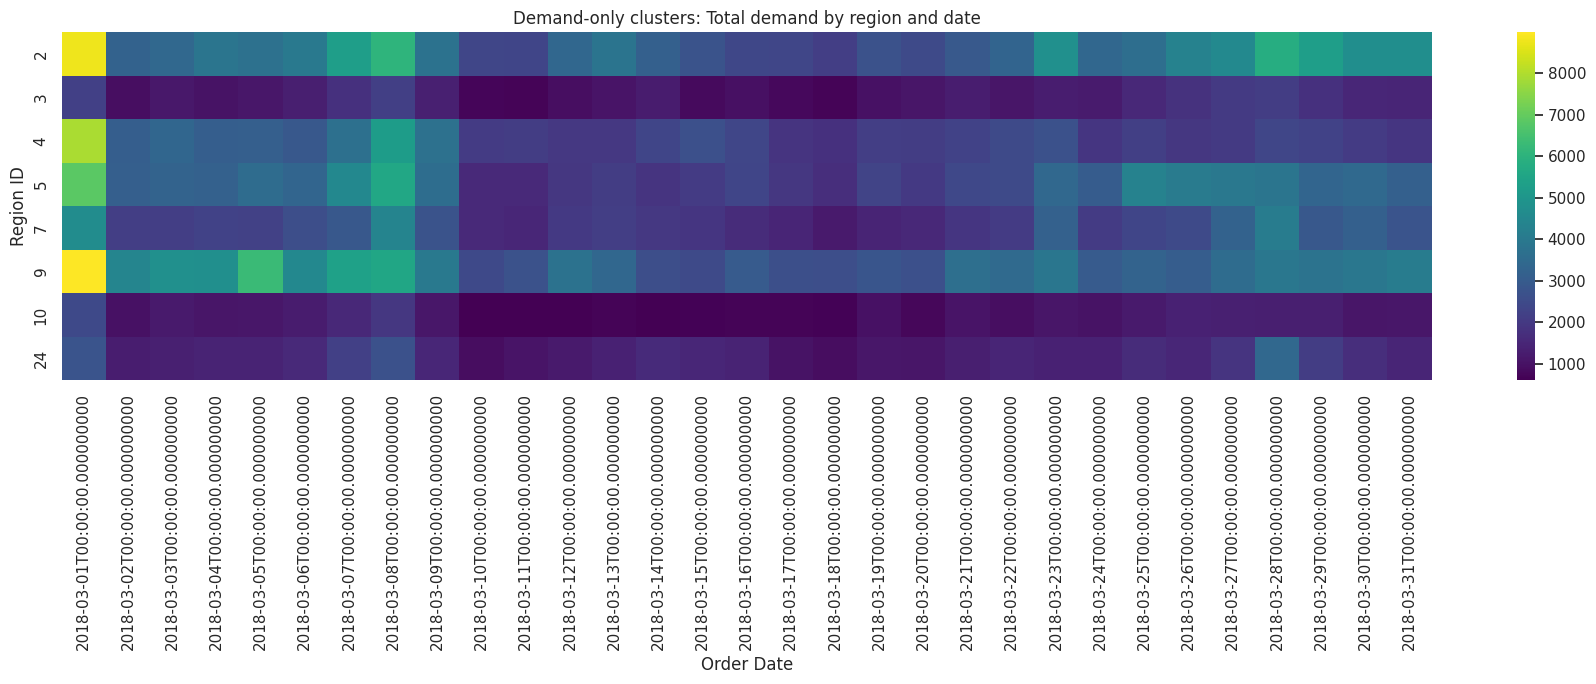

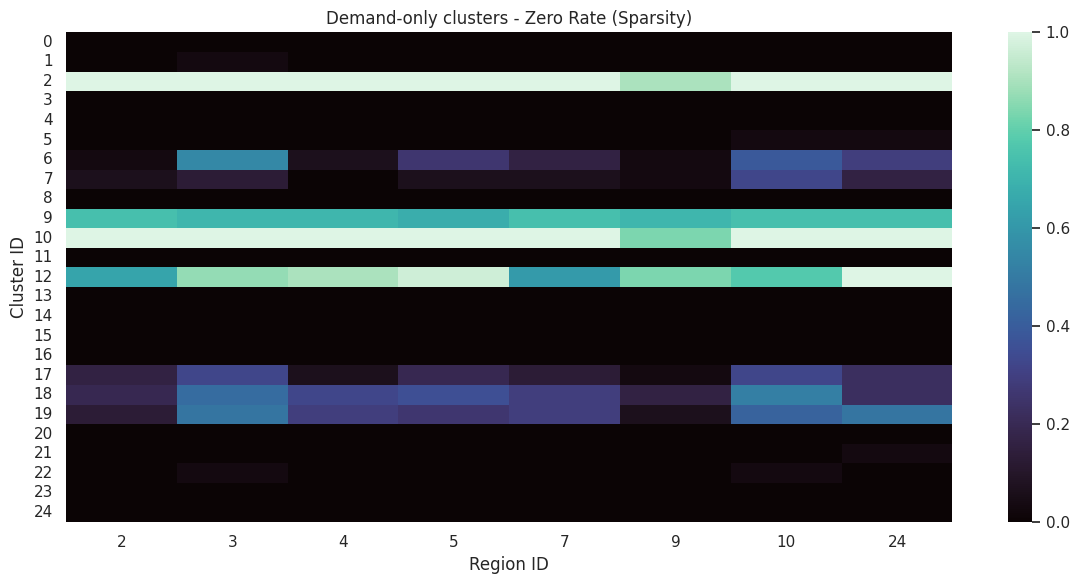

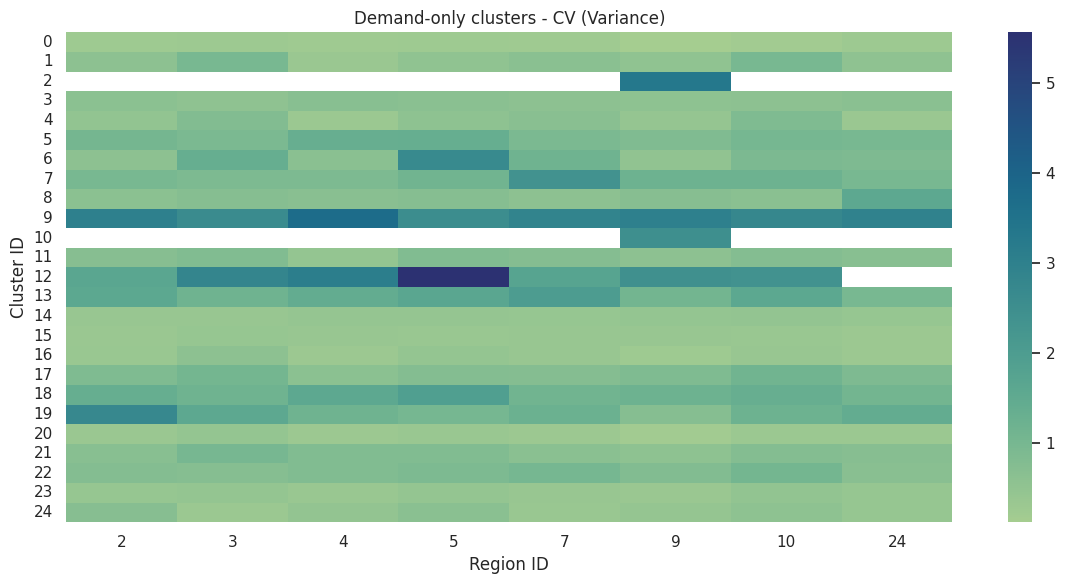

In [8]:
if demand_grid_demand_path.exists():
    demand_full_demand = pd.read_csv(demand_grid_demand_path, parse_dates=['order_date'])
else:
    demand_full_demand = build_demand_grid(orders, clusters_demand, network)

metrics_demand = compute_sparsity_variance(demand_full_demand)
plot_region_date_heatmap(demand_full_demand, 'Demand-only clusters: Total demand by region and date')
plot_sparsity_variance_heatmaps(metrics_demand, 'Demand-only clusters')


### Per-cluster SKU distributions (demand-only)
This will generate one pair of plots per cluster. It can be a lot of figures.


/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


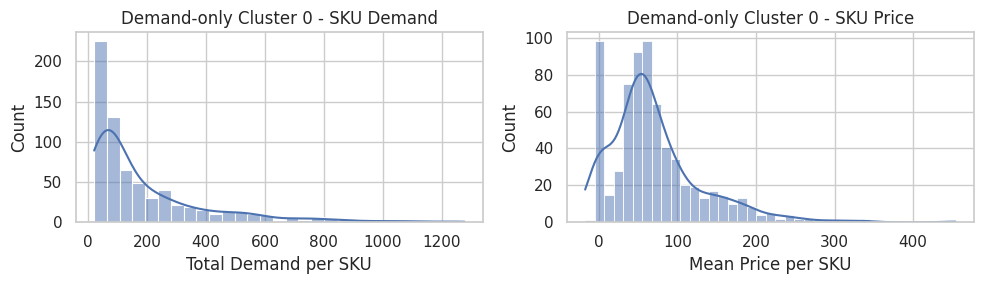

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


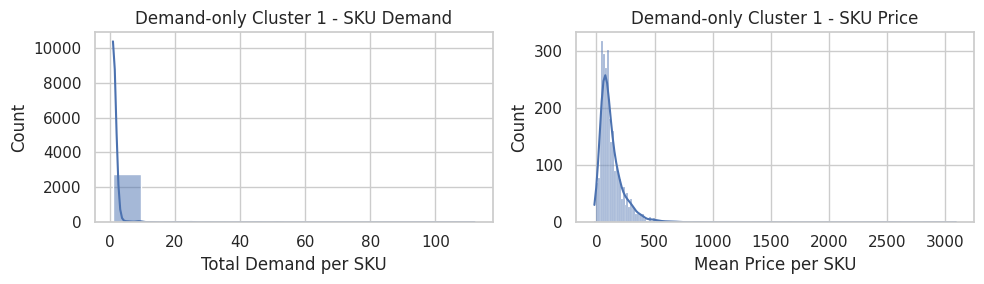

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


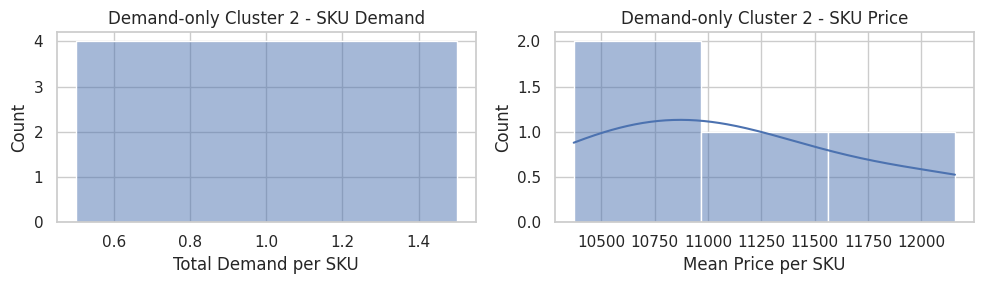

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


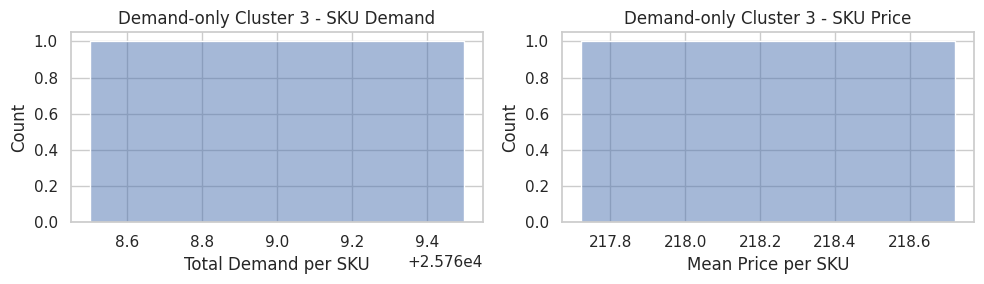

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


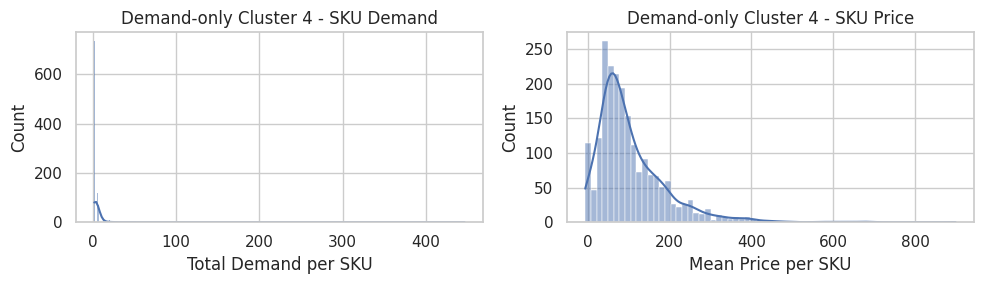

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


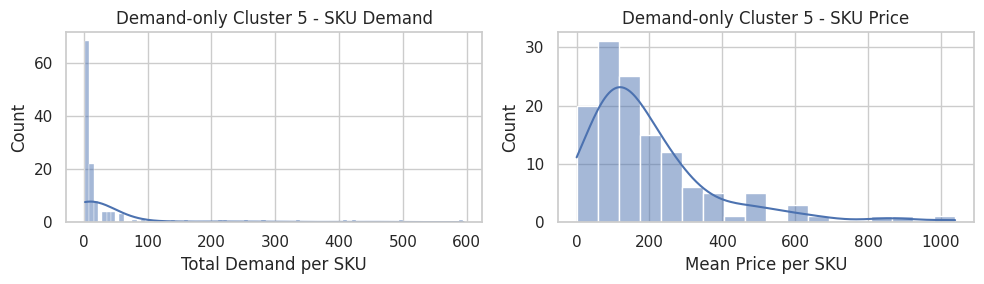

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


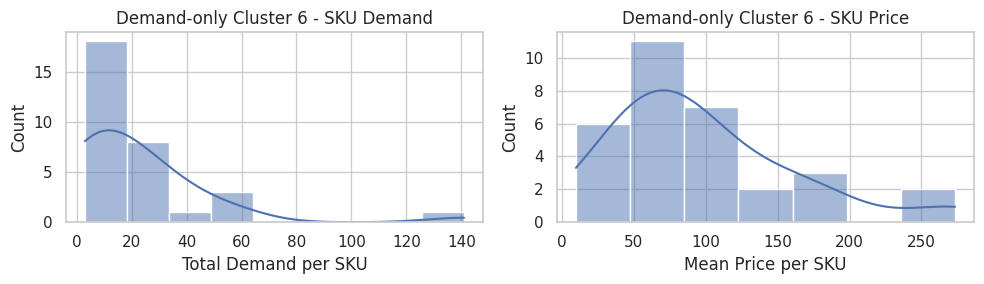

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


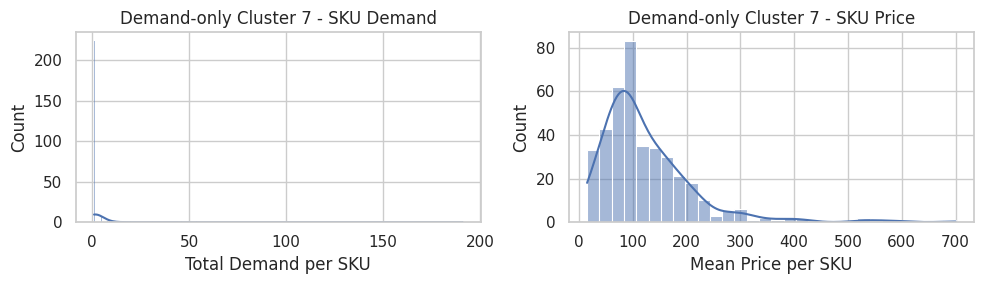

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


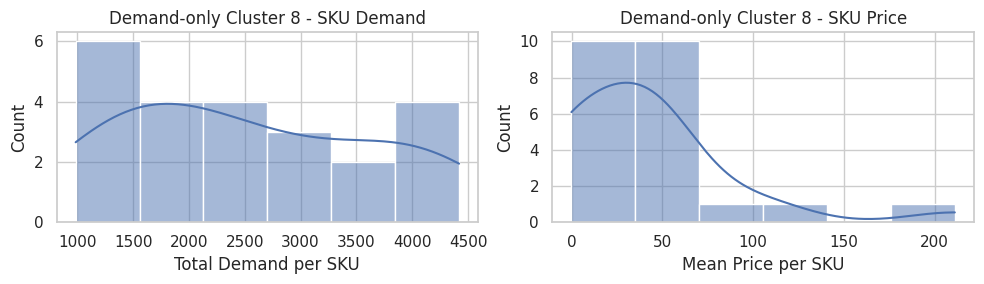

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


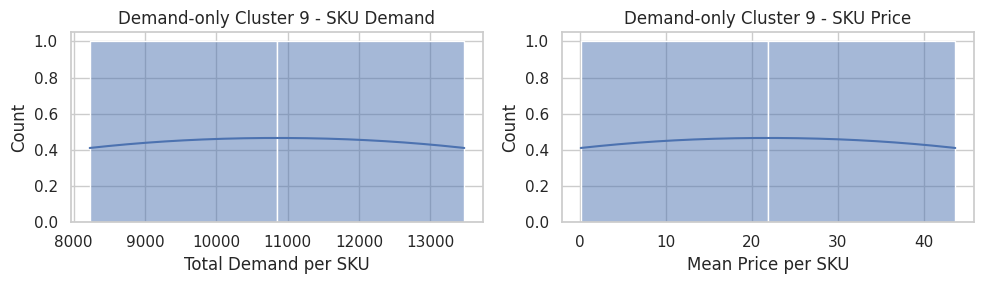

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


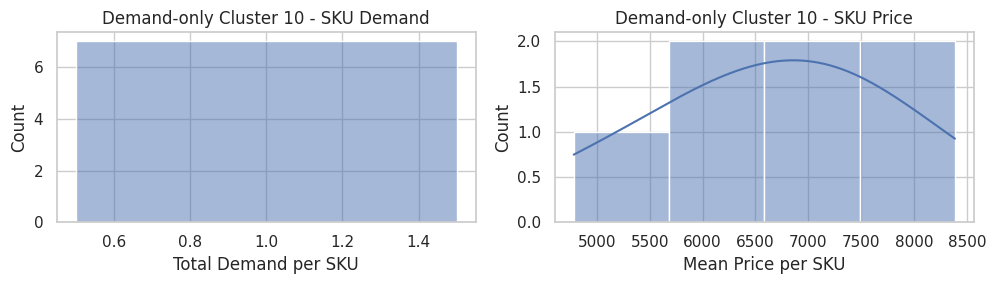

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


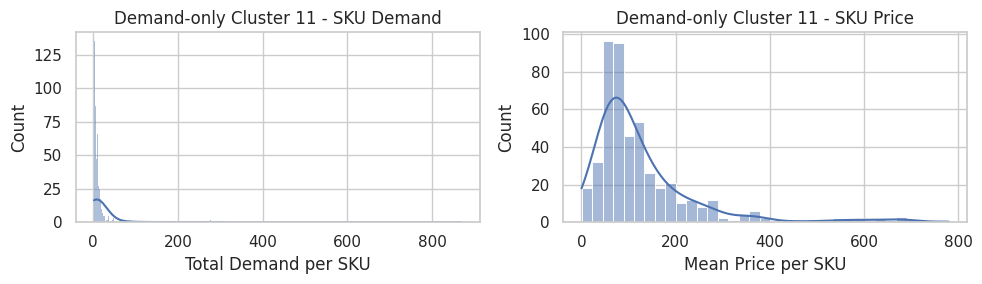

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


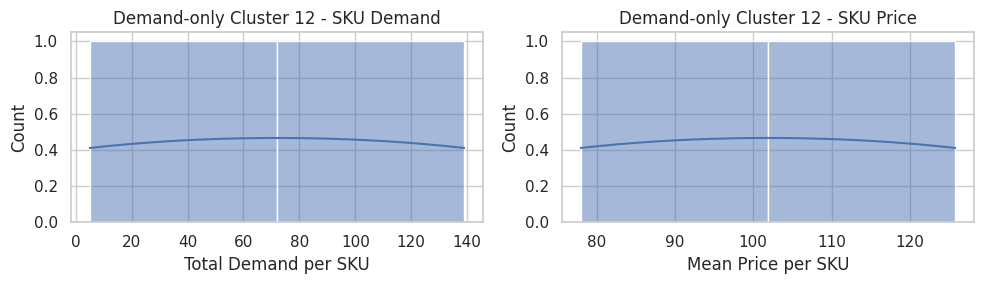

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


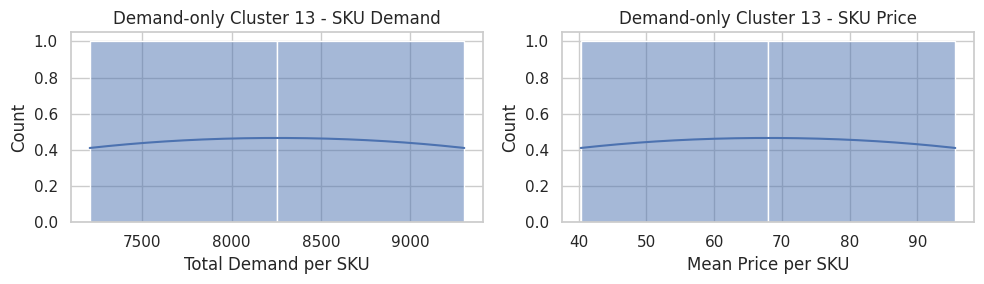

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


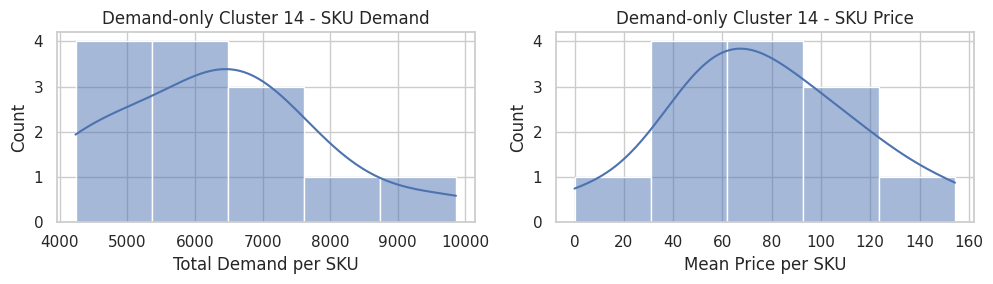

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


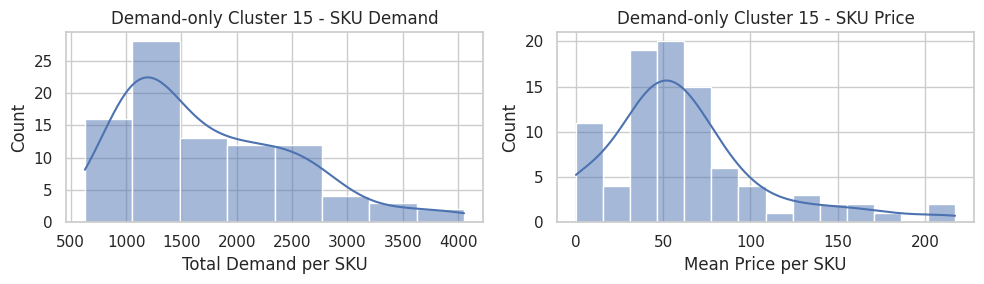

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


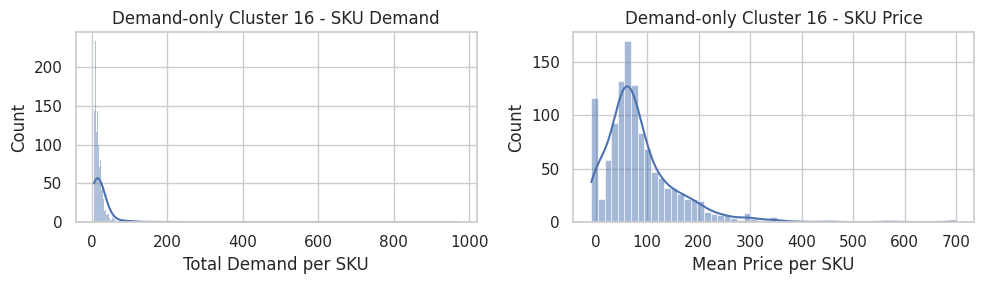

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


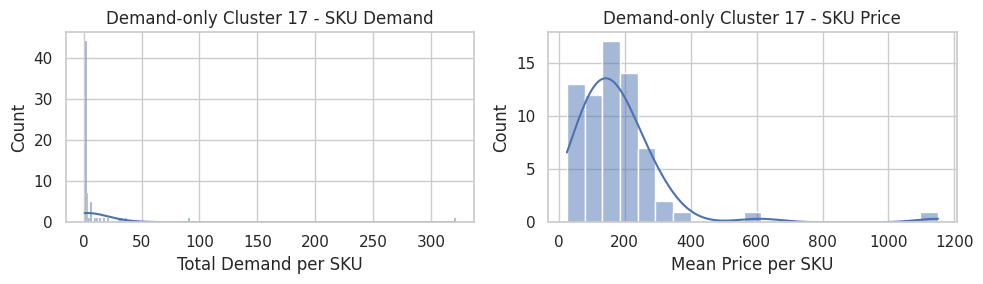

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


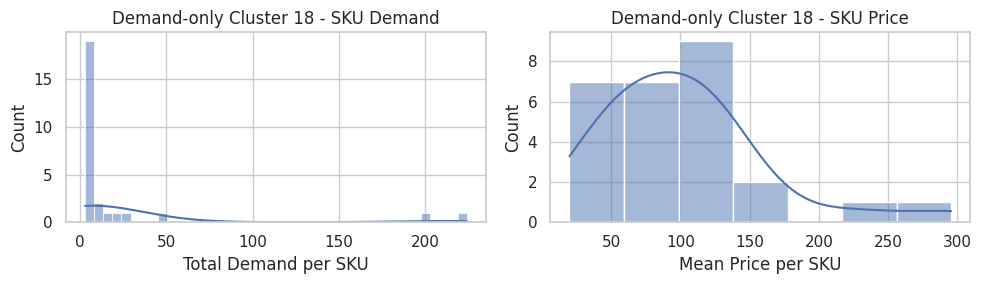

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


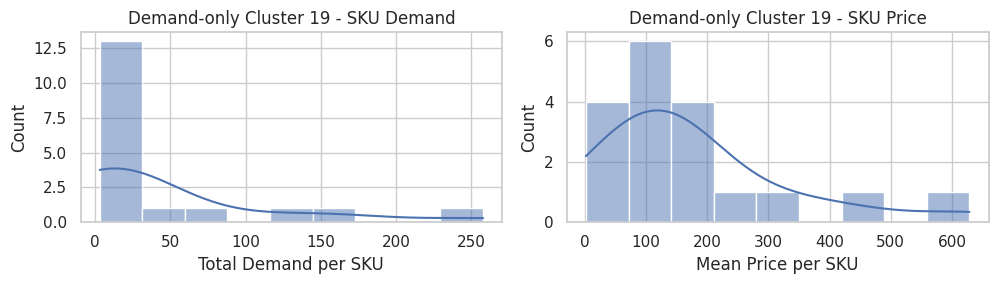

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


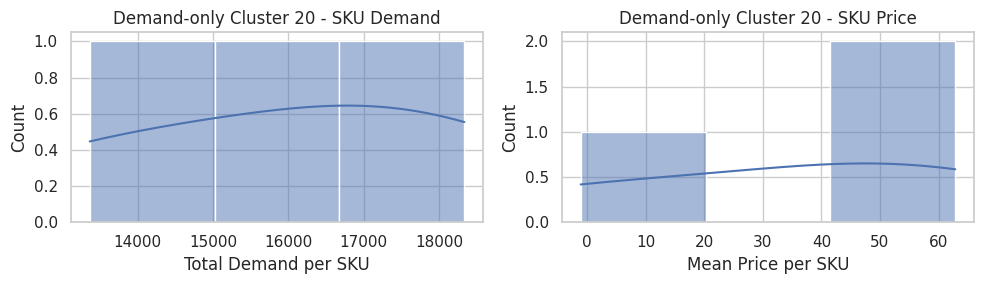

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


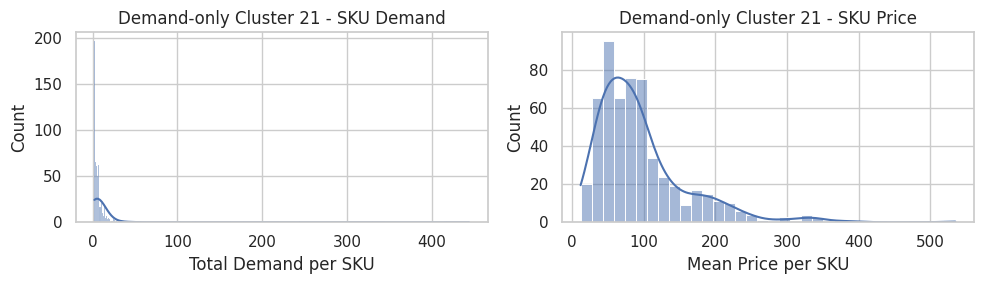

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


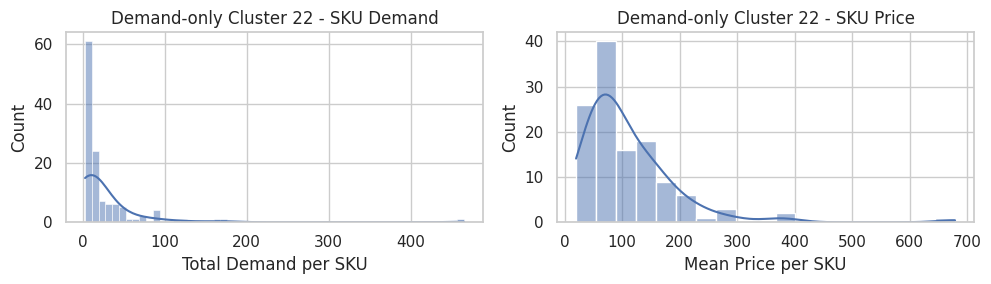

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


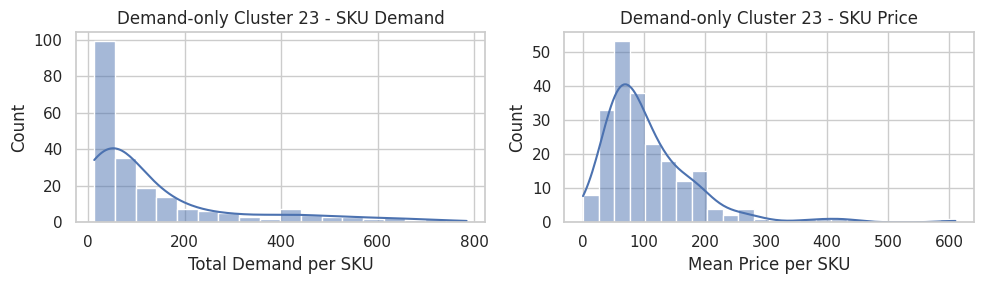

/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/kexin/.local/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


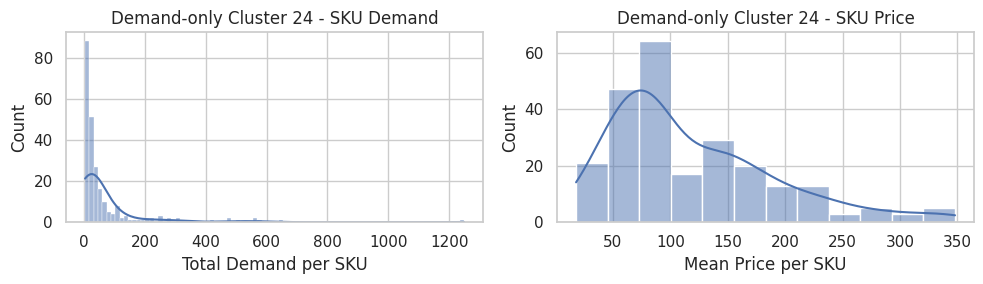

In [5]:
sku_metrics_demand = build_sku_level_metrics(orders, clusters_demand)
plot_cluster_distributions(sku_metrics_demand, 'Demand-only')


## Price/promo clusters


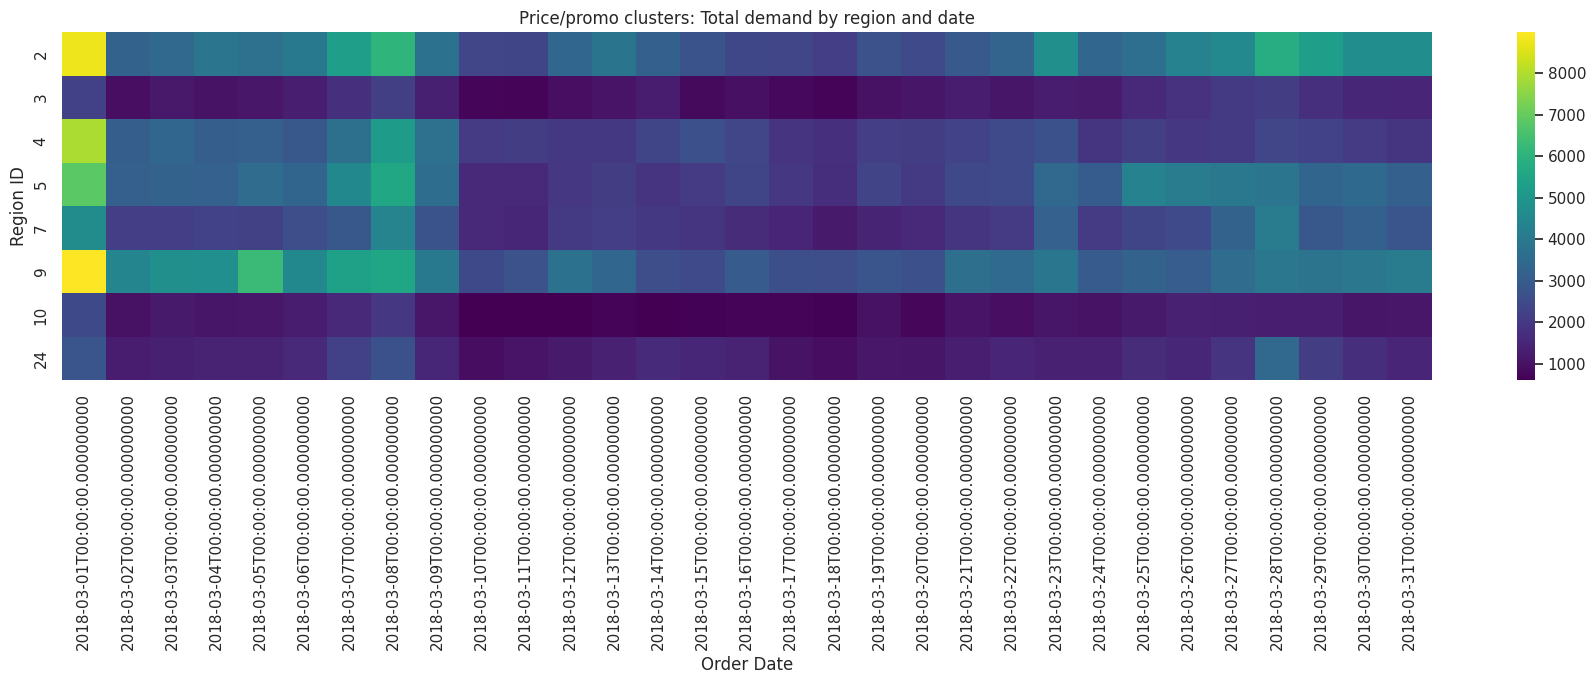

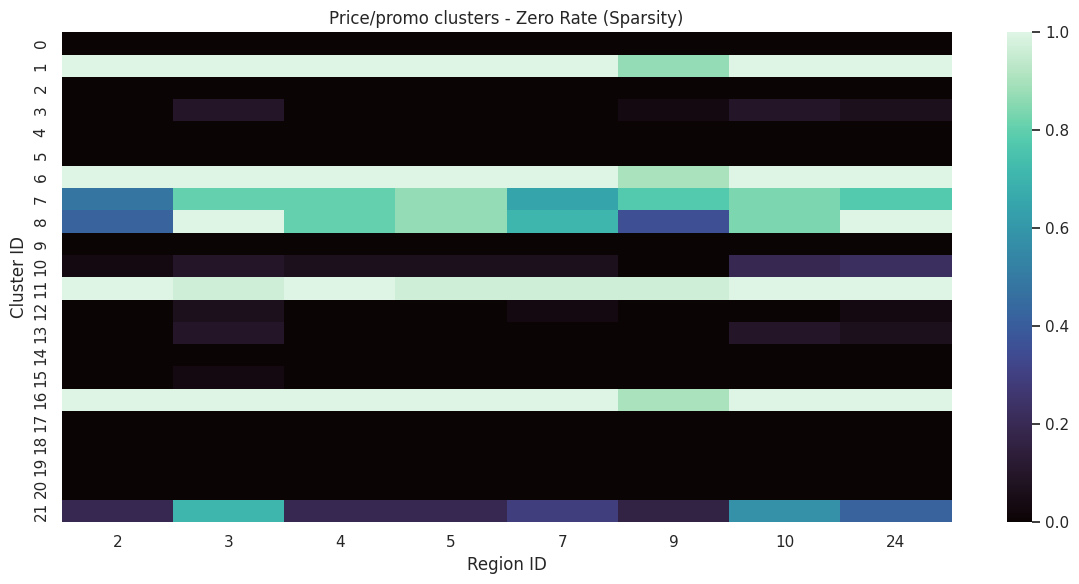

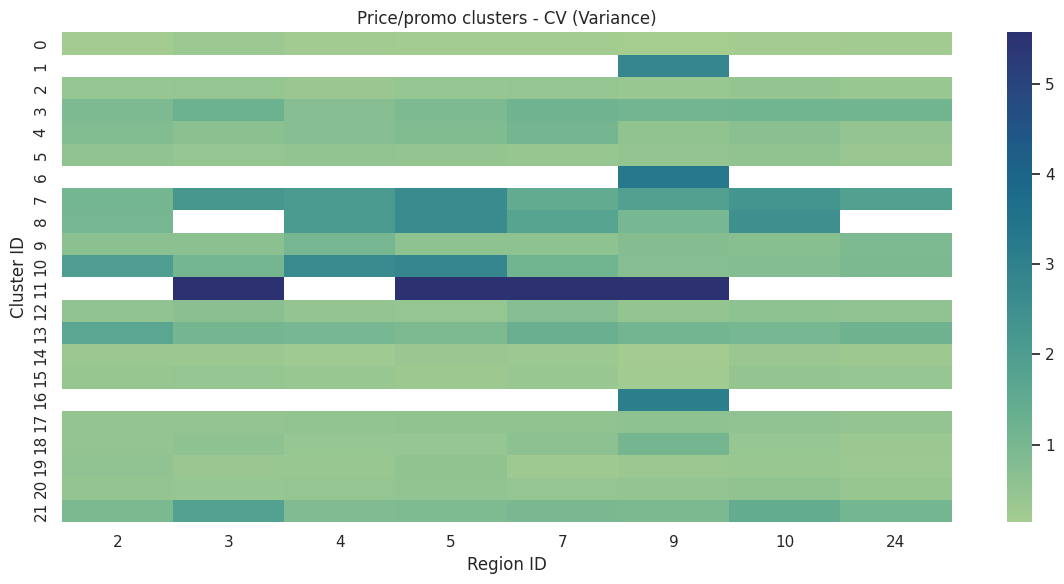

In [9]:
if demand_grid_price_path.exists():
    demand_full_price = pd.read_csv(demand_grid_price_path, parse_dates=['order_date'])
else:
    demand_full_price = build_demand_grid(orders, clusters_price, network)

metrics_price = compute_sparsity_variance(demand_full_price)
plot_region_date_heatmap(demand_full_price, 'Price/promo clusters: Total demand by region and date')
plot_sparsity_variance_heatmaps(metrics_price, 'Price/promo clusters')


### Per-cluster SKU distributions (price/promo)
This will generate one pair of plots per cluster. It can be a lot of figures.


In [ ]:
sku_metrics_price = build_sku_level_metrics(orders, clusters_price)
plot_cluster_distributions(sku_metrics_price, 'Price/promo')
